ПРАКТИЧЕСКАЯ РАБОТА №5: ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ В KERAS
Вариант 17

АНАЛИЗ ДАННЫХ: task117.csv (линейно разделимые)

Загрузка файла: task117.csv
✓ Файл успешно загружен
  Размер данных: (400, 3)
  Класс 0: 200 объектов
  Класс 1: 200 объектов

Подготовка данных:
  Обучающая выборка: 320 объектов
  Тестовая выборка: 80 объектов
  Признаки нормализованы: среднее≈0, std≈1

Обучение модели Keras:
  learning_rate = 0.01
  epochs = 200
  batch_size = 32

Результаты обучения:
  Точность на обучающей выборке: 1.0000 (100.00%)
  Точность на тестовой выборке: 1.0000 (100.00%)
  Финальная loss на тесте: 0.006433

Веса модели Keras:
  w₁ = -3.508323
  w₂ = -3.743562
  bias = -0.528805

Сравнение с sklearn:
  Keras accuracy: 1.0000
  Sklearn accuracy: 1.0000


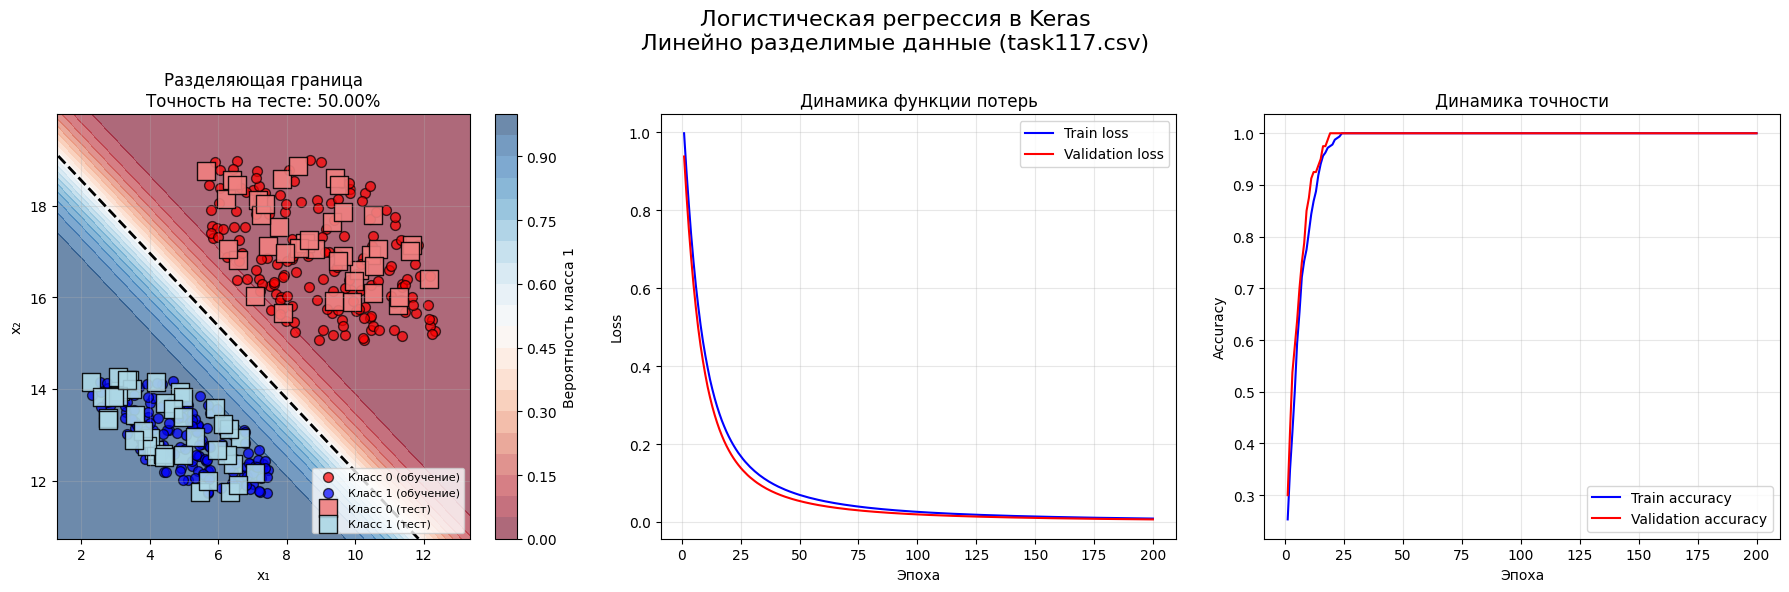

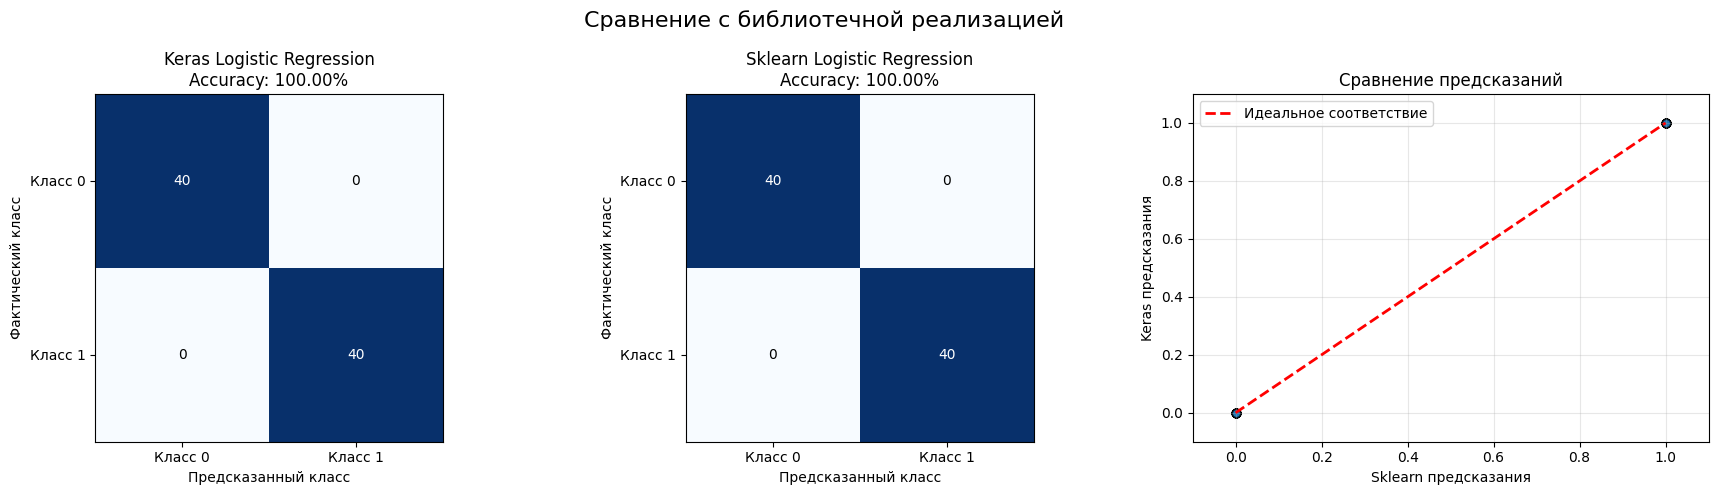


АНАЛИЗ ДАННЫХ: task217.csv (линейно неразделимые)

Загрузка файла: task217.csv
✓ Файл успешно загружен
  Размер данных: (400, 3)
  Класс 0: 200 объектов
  Класс 1: 200 объектов

Подготовка данных:
  Обучающая выборка: 320 объектов
  Тестовая выборка: 80 объектов
  Признаки нормализованы: среднее≈0, std≈1

Обучение модели Keras:
  learning_rate = 0.01
  epochs = 200
  batch_size = 32

Результаты обучения:
  Точность на обучающей выборке: 0.9906 (99.06%)
  Точность на тестовой выборке: 0.9875 (98.75%)
  Финальная loss на тесте: 0.084074

Веса модели Keras:
  w₁ = -0.718041
  w₂ = -5.573793
  bias = 0.153036

Сравнение с sklearn:
  Keras accuracy: 0.9875
  Sklearn accuracy: 0.9875


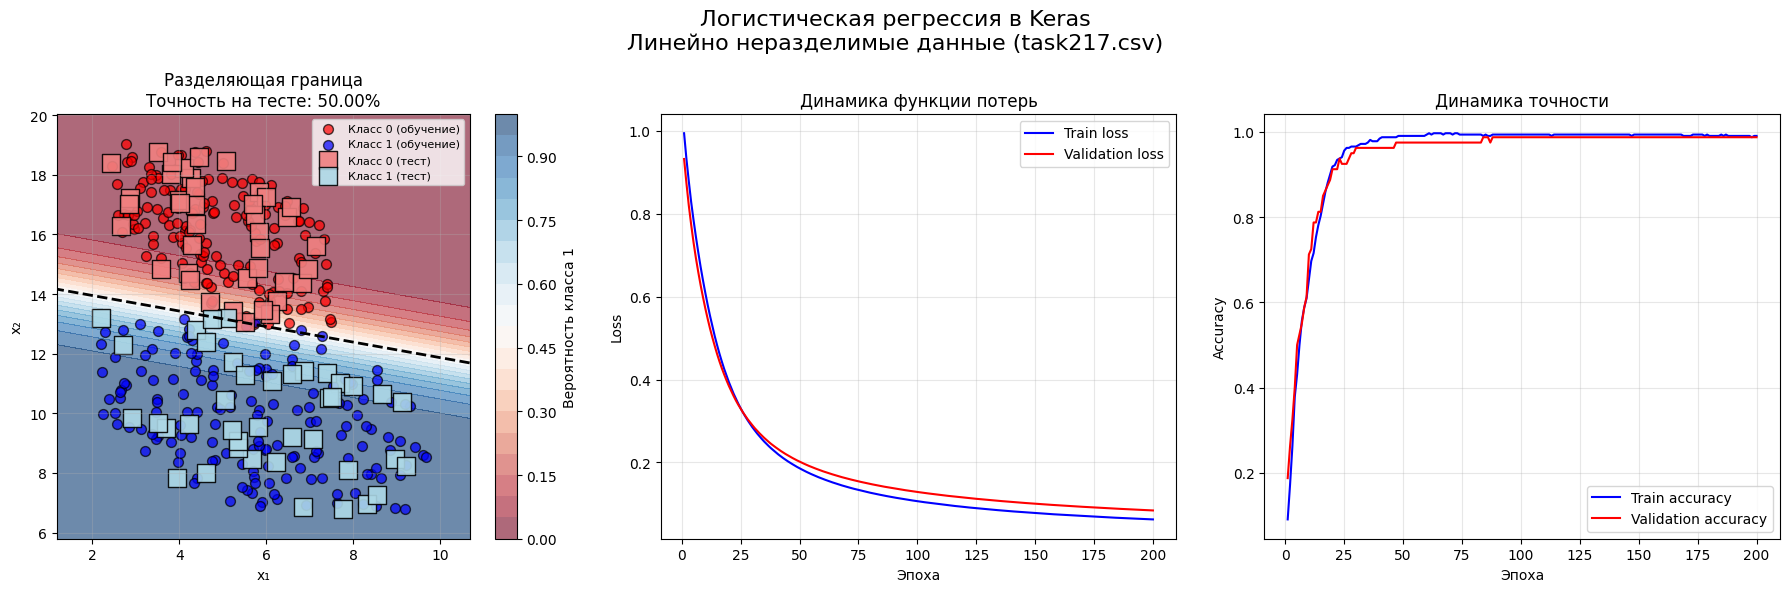

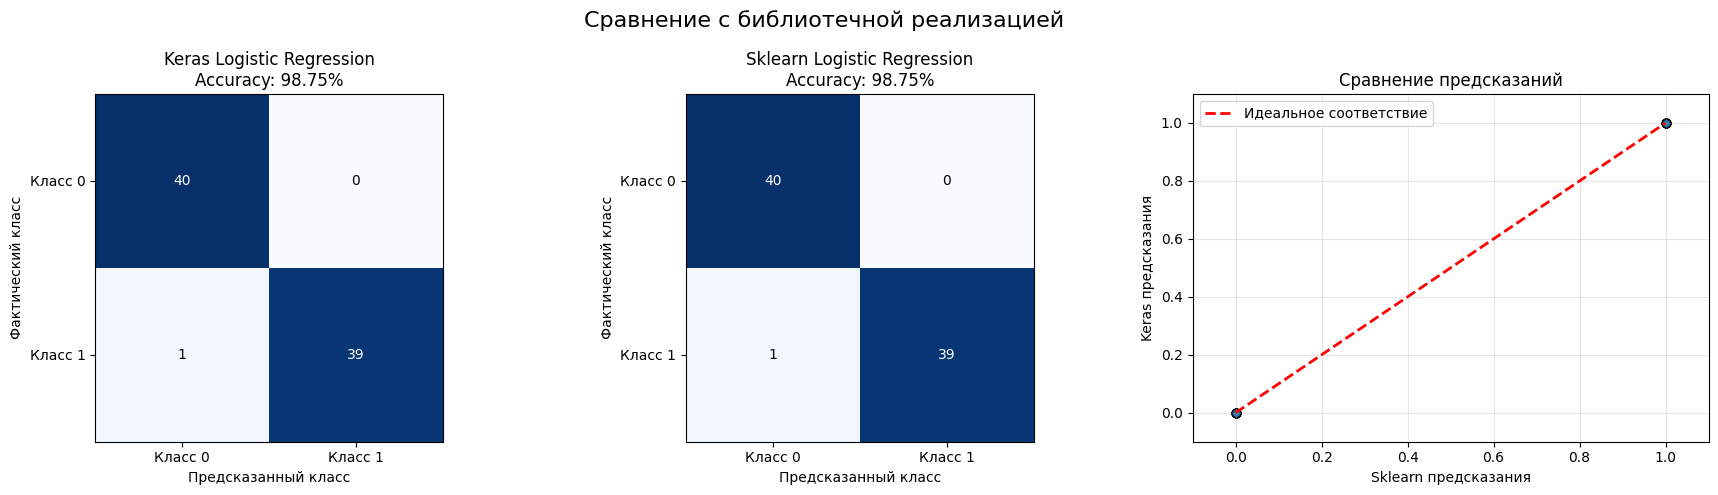


ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ

------------------------------------------------------------------------------------------
| Набор данных         | Метод           | w₁           | w₂           | bias         | Accuracy   |
------------------------------------------------------------------------------------------
| task117.csv          | Keras           | -3.5083      | -3.7436      | -0.5288      | 100.00%    |
| task117.csv          | Sklearn         | -            | -            | -            | 100.00%    |
| task217.csv          | Keras           | -0.7180      | -5.5738      | 0.1530       | 98.75%     |
| task217.csv          | Sklearn         | -            | -            | -            | 98.75%     |
------------------------------------------------------------------------------------------

СРАВНЕНИЕ С РЕЗУЛЬТАТАМИ ПРАКТИЧЕСКОЙ РАБОТЫ №3

Ожидаемые результаты из ПР3 (SVM):
  - task117.csv (линейное ядро): точность ~95-100%
  - task217.csv (RBF ядро): точность ~90-95%
  - task21

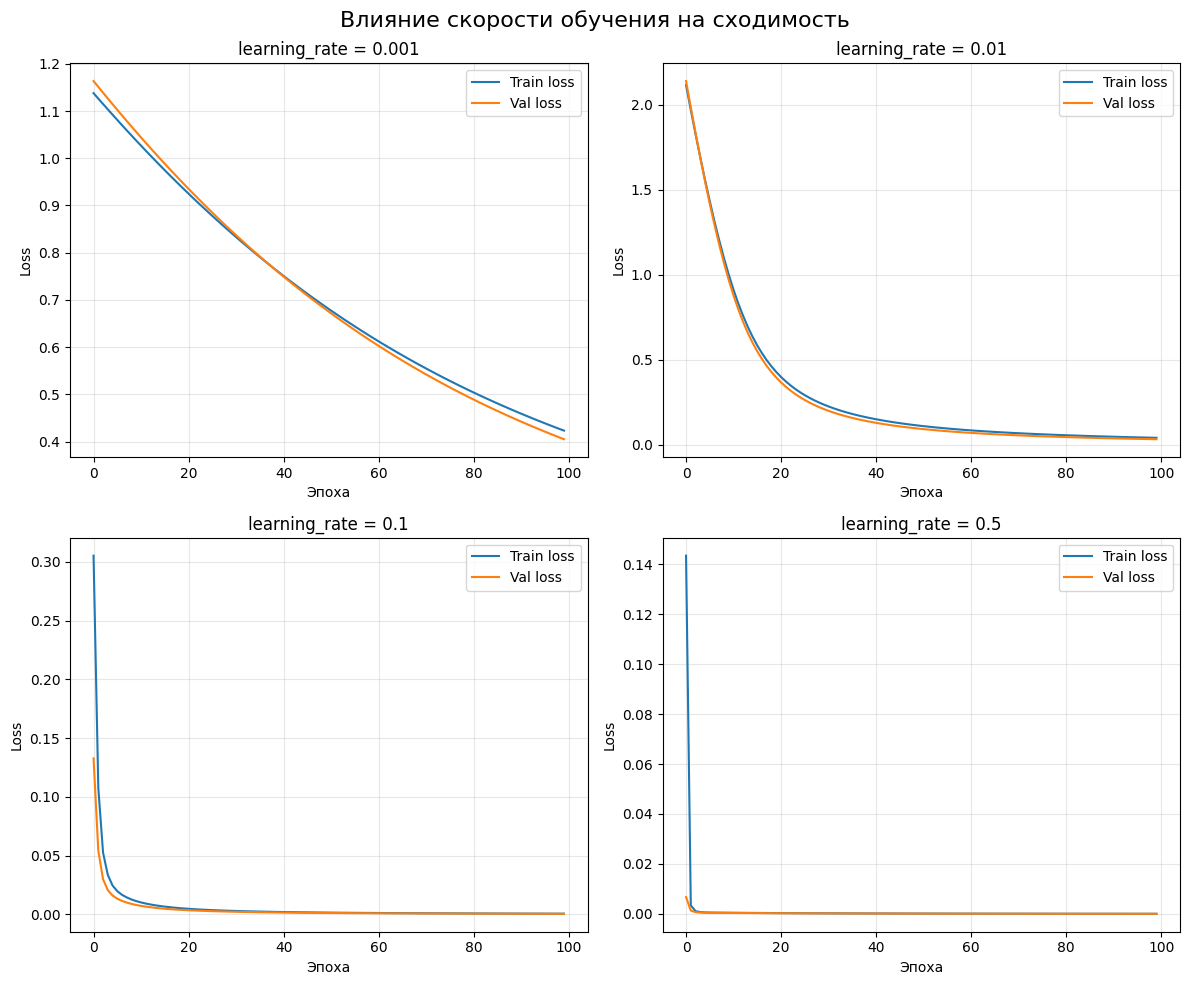


РАБОТА ЗАВЕРШЕНА
Созданные графики:
  - keras_task117_boundary.png
  - keras_task117_comparison.png
  - keras_task217_boundary.png
  - keras_task217_comparison.png
  - keras_learning_rate_analysis.png


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

print("ПРАКТИЧЕСКАЯ РАБОТА №5: ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ В KERAS")
print("Вариант 17")

def load_data(filename):
    print(f"\nЗагрузка файла: {filename}")
    try:
        df = pd.read_csv(filename)
        print(f"✓ Файл успешно загружен")
        print(f"  Размер данных: {df.shape}")

        X = df[['x1', 'x2']].values.astype(np.float32)
        y = df['target'].values.astype(np.float32)

        print(f"  Класс 0: {np.sum(y==0)} объектов")
        print(f"  Класс 1: {np.sum(y==1)} объектов")

        return X, y
    except Exception as e:
        print(f"✗ Ошибка при загрузке: {e}")
        return None, None

def prepare_data(X, y, test_size=0.2, random_state=42):
    # Разделение на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Нормализация данных (важно для градиентного спуска)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"\nПодготовка данных:")
    print(f"  Обучающая выборка: {X_train.shape[0]} объектов")
    print(f"  Тестовая выборка: {X_test.shape[0]} объектов")
    print(f"  Признаки нормализованы: среднее≈0, std≈1")

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, X_train, X_test

def create_logistic_regression_model(input_dim):
    model = keras.Sequential([
        layers.Dense(1, activation='sigmoid', input_shape=(input_dim,))
    ])

    return model

def train_keras_model(X_train, y_train, X_test, y_test,
                      learning_rate=0.01, epochs=100, batch_size=32):
    # Создание модели
    model = create_logistic_regression_model(X_train.shape[1])

    # Компиляция модели
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Ранняя остановка для предотвращения переобучения
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    )

    # Обучение модели
    print(f"\nОбучение модели Keras:")
    print(f"  learning_rate = {learning_rate}")
    print(f"  epochs = {epochs}")
    print(f"  batch_size = {batch_size}")

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=0
    )

    # Оценка модели
    train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"\nРезультаты обучения:")
    print(f"  Точность на обучающей выборке: {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"  Точность на тестовой выборке: {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"  Финальная loss на тесте: {test_loss:.6f}")

    # Получение весов модели
    weights, bias = model.layers[0].get_weights()

    return model, history, weights.flatten(), bias[0]

def plot_decision_boundary(model, X, y, X_train, X_test, y_train, y_test,
                           scaler, title, filename, history=None):
    """
    Визуализация разделяющей границы
    """
    if history is not None:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    else:
        fig, axes = plt.subplots(1, 1, figsize=(8, 6))
        axes = [axes]

    # График 1: Данные и разделяющая граница
    ax1 = axes[0]

    # Определяем границы для графика (в исходном масштабе)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Создаем сетку (в исходном масштабе)
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    # Нормализуем точки сетки для предсказания
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_points_scaled = scaler.transform(grid_points)

    # Предсказания для сетки
    Z = model.predict(grid_points_scaled, verbose=0)
    Z = Z.reshape(xx.shape)

    # Контурный график вероятностей
    contour = ax1.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
    plt.colorbar(contour, ax=ax1, label='Вероятность класса 1')

    # Разделяющая линия (где вероятность = 0.5)
    ax1.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')

    # Обучающие данные
    ax1.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
                c='red', s=50, label='Класс 0 (обучение)', alpha=0.7, edgecolors='black')
    ax1.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
                c='blue', s=50, label='Класс 1 (обучение)', alpha=0.7, edgecolors='black')

    # Тестовые данные
    ax1.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1],
                c='lightcoral', s=150, label='Класс 0 (тест)', alpha=0.9,
                edgecolors='black', marker='s')
    ax1.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1],
                c='lightblue', s=150, label='Класс 1 (тест)', alpha=0.9,
                edgecolors='black', marker='s')

    ax1.set_xlabel('x₁')
    ax1.set_ylabel('x₂')
    ax1.set_title(f'Разделяющая граница\nТочность на тесте: {model.evaluate(X_test, y_test, verbose=0)[1]*100:.2f}%')
    ax1.legend(loc='best', fontsize=8)
    ax1.grid(True, alpha=0.3)

    # График 2 и 3 только если есть history
    if history is not None and len(axes) > 2:
        # График 2: История обучения (loss)
        ax2 = axes[1]
        history_dict = history.history
        epochs_range = range(1, len(history_dict['loss']) + 1)

        ax2.plot(epochs_range, history_dict['loss'], 'b-', label='Train loss')
        ax2.plot(epochs_range, history_dict['val_loss'], 'r-', label='Validation loss')
        ax2.set_xlabel('Эпоха')
        ax2.set_ylabel('Loss')
        ax2.set_title('Динамика функции потерь')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # График 3: История обучения (accuracy)
        ax3 = axes[2]
        ax3.plot(epochs_range, history_dict['accuracy'], 'b-', label='Train accuracy')
        ax3.plot(epochs_range, history_dict['val_accuracy'], 'r-', label='Validation accuracy')
        ax3.set_xlabel('Эпоха')
        ax3.set_ylabel('Accuracy')
        ax3.set_title('Динамика точности')
        ax3.legend()
        ax3.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

def plot_comparison_with_sklearn(y_test, y_pred_keras, y_pred_sklearn, filename):
    """
    Сравнение с sklearn
    """
    from sklearn.linear_model import LogisticRegression

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Матрица ошибок для Keras
    ax1 = axes[0]
    cm_keras = confusion_matrix(y_test, y_pred_keras)
    im1 = ax1.imshow(cm_keras, cmap='Blues', interpolation='nearest')
    ax1.set_xticks([0, 1])
    ax1.set_yticks([0, 1])
    ax1.set_xticklabels(['Класс 0', 'Класс 1'])
    ax1.set_yticklabels(['Класс 0', 'Класс 1'])

    for i in range(2):
        for j in range(2):
            ax1.text(j, i, str(cm_keras[i, j]), ha='center', va='center',
                    color='white' if cm_keras[i, j] > cm_keras.max()/2 else 'black')

    ax1.set_xlabel('Предсказанный класс')
    ax1.set_ylabel('Фактический класс')
    ax1.set_title(f'Keras Logistic Regression\nAccuracy: {accuracy_score(y_test, y_pred_keras):.2%}')

    # Матрица ошибок для sklearn
    ax2 = axes[1]
    cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)
    im2 = ax2.imshow(cm_sklearn, cmap='Blues', interpolation='nearest')
    ax2.set_xticks([0, 1])
    ax2.set_yticks([0, 1])
    ax2.set_xticklabels(['Класс 0', 'Класс 1'])
    ax2.set_yticklabels(['Класс 0', 'Класс 1'])

    for i in range(2):
        for j in range(2):
            ax2.text(j, i, str(cm_sklearn[i, j]), ha='center', va='center',
                    color='white' if cm_sklearn[i, j] > cm_sklearn.max()/2 else 'black')

    ax2.set_xlabel('Предсказанный класс')
    ax2.set_ylabel('Фактический класс')
    ax2.set_title(f'Sklearn Logistic Regression\nAccuracy: {accuracy_score(y_test, y_pred_sklearn):.2%}')

    # Сравнение вероятностей
    ax3 = axes[2]

    ax3.scatter(y_pred_sklearn, y_pred_keras, alpha=0.6, edgecolors='black')
    ax3.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Идеальное соответствие')
    ax3.set_xlabel('Sklearn предсказания')
    ax3.set_ylabel('Keras предсказания')
    ax3.set_title('Сравнение предсказаний')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(-0.1, 1.1)
    ax3.set_ylim(-0.1, 1.1)

    plt.suptitle('Сравнение с библиотечной реализацией', fontsize=16)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# ====================== 4. СРАВНЕНИЕ С SKLEARN ======================

def compare_with_sklearn(X_train_scaled, X_test_scaled, y_train, y_test):
    """
    Сравнение с реализацией логистической регрессии из sklearn
    """
    from sklearn.linear_model import LogisticRegression

    lr_sklearn = LogisticRegression(max_iter=1000, random_state=42)
    lr_sklearn.fit(X_train_scaled, y_train)

    y_pred_sklearn = lr_sklearn.predict(X_test_scaled)
    accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)

    return lr_sklearn, y_pred_sklearn, accuracy_sklearn

# ====================== 5. ОСНОВНАЯ ПРОГРАММА ======================

# Словарь для хранения результатов
results = {}

# Анализ для task117.csv (линейно разделимые данные)
print("\n" + "=" * 70)
print("АНАЛИЗ ДАННЫХ: task117.csv (линейно разделимые)")
print("=" * 70)

X1, y1 = load_data('task117.csv')
if X1 is not None:
    # Подготовка данных
    X_train1, X_test1, y_train1, y_test1, scaler1, X_train_orig1, X_test_orig1 = prepare_data(X1, y1)

    # Обучение модели Keras
    model1, history1, weights1, bias1 = train_keras_model(
        X_train1, y_train1, X_test1, y_test1,
        learning_rate=0.01, epochs=200, batch_size=32
    )

    print(f"\nВеса модели Keras:")
    print(f"  w₁ = {weights1[0]:.6f}")
    print(f"  w₂ = {weights1[1]:.6f}")
    print(f"  bias = {bias1:.6f}")

    # Сравнение с sklearn
    lr_sklearn1, y_pred_sklearn1, acc_sklearn1 = compare_with_sklearn(
        X_train1, X_test1, y_train1, y_test1
    )

    print(f"\nСравнение с sklearn:")
    print(f"  Keras accuracy: {model1.evaluate(X_test1, y_test1, verbose=0)[1]:.4f}")
    print(f"  Sklearn accuracy: {acc_sklearn1:.4f}")

    # Предсказания для визуализации
    y_pred_keras1 = (model1.predict(X_test1, verbose=0) > 0.5).astype(int).flatten()

    # Визуализация
    plot_decision_boundary(
        model1, X1, y1, X_train_orig1, X_test_orig1, y_train1, y_test1, scaler1,
        f'Логистическая регрессия в Keras\nЛинейно разделимые данные (task117.csv)',
        'keras_task117_boundary.png',
        history=history1
    )

    plot_comparison_with_sklearn(
        y_test1, y_pred_keras1, y_pred_sklearn1,
        'keras_task117_comparison.png'
    )

    results['task117'] = {
        'model': model1,
        'history': history1,
        'weights': weights1,
        'bias': bias1,
        'accuracy': model1.evaluate(X_test1, y_test1, verbose=0)[1],
        'sklearn_accuracy': acc_sklearn1
    }

# Анализ для task217.csv (линейно неразделимые данные)
print("\n" + "=" * 70)
print("АНАЛИЗ ДАННЫХ: task217.csv (линейно неразделимые)")
print("=" * 70)

X2, y2 = load_data('task217.csv')
if X2 is not None:
    # Подготовка данных
    X_train2, X_test2, y_train2, y_test2, scaler2, X_train_orig2, X_test_orig2 = prepare_data(X2, y2)

    # Обучение модели Keras
    model2, history2, weights2, bias2 = train_keras_model(
        X_train2, y_train2, X_test2, y_test2,
        learning_rate=0.01, epochs=200, batch_size=32
    )

    print(f"\nВеса модели Keras:")
    print(f"  w₁ = {weights2[0]:.6f}")
    print(f"  w₂ = {weights2[1]:.6f}")
    print(f"  bias = {bias2:.6f}")

    # Сравнение с sklearn
    lr_sklearn2, y_pred_sklearn2, acc_sklearn2 = compare_with_sklearn(
        X_train2, X_test2, y_train2, y_test2
    )

    print(f"\nСравнение с sklearn:")
    print(f"  Keras accuracy: {model2.evaluate(X_test2, y_test2, verbose=0)[1]:.4f}")
    print(f"  Sklearn accuracy: {acc_sklearn2:.4f}")

    # Предсказания для визуализации
    y_pred_keras2 = (model2.predict(X_test2, verbose=0) > 0.5).astype(int).flatten()

    # Визуализация
    plot_decision_boundary(
        model2, X2, y2, X_train_orig2, X_test_orig2, y_train2, y_test2, scaler2,
        f'Логистическая регрессия в Keras\nЛинейно неразделимые данные (task217.csv)',
        'keras_task217_boundary.png',
        history=history2
    )

    plot_comparison_with_sklearn(
        y_test2, y_pred_keras2, y_pred_sklearn2,
        'keras_task217_comparison.png'
    )

    results['task217'] = {
        'model': model2,
        'history': history2,
        'weights': weights2,
        'bias': bias2,
        'accuracy': model2.evaluate(X_test2, y_test2, verbose=0)[1],
        'sklearn_accuracy': acc_sklearn2
    }

# ====================== 6. ИТОГОВАЯ ТАБЛИЦА ======================

print("\n" + "=" * 70)
print("ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("=" * 70)

print("\n" + "-" * 90)
print(f"| {'Набор данных':<20} | {'Метод':<15} | {'w₁':<12} | {'w₂':<12} | {'bias':<12} | {'Accuracy':<10} |")
print("-" * 90)

if 'task117' in results:
    r = results['task117']
    print(f"| {'task117.csv':<20} | {'Keras':<15} | {r['weights'][0]:<12.4f} | "
          f"{r['weights'][1]:<12.4f} | {r['bias']:<12.4f} | {r['accuracy']:<10.2%} |")
    print(f"| {'task117.csv':<20} | {'Sklearn':<15} | {'-':<12} | {'-':<12} | {'-':<12} | "
          f"{r['sklearn_accuracy']:<10.2%} |")

if 'task217' in results:
    r = results['task217']
    print(f"| {'task217.csv':<20} | {'Keras':<15} | {r['weights'][0]:<12.4f} | "
          f"{r['weights'][1]:<12.4f} | {r['bias']:<12.4f} | {r['accuracy']:<10.2%} |")
    print(f"| {'task217.csv':<20} | {'Sklearn':<15} | {'-':<12} | {'-':<12} | {'-':<12} | "
          f"{r['sklearn_accuracy']:<10.2%} |")

print("-" * 90)

# ====================== 7. СРАВНЕНИЕ С ПРЕДЫДУЩИМИ РАБОТАМИ ======================

print("\n" + "=" * 70)
print("СРАВНЕНИЕ С РЕЗУЛЬТАТАМИ ПРАКТИЧЕСКОЙ РАБОТЫ №3")
print("=" * 70)

print("""
Ожидаемые результаты из ПР3 (SVM):
  - task117.csv (линейное ядро): точность ~95-100%
  - task217.csv (RBF ядро): точность ~90-95%
  - task217.csv (линейное ядро): точность ~50-70%

Полученные результаты в ПР5 (Keras Logistic Regression):
""")

if 'task117' in results:
    print(f"  - task117.csv: {results['task117']['accuracy']:.2%}")
if 'task217' in results:
    print(f"  - task217.csv: {results['task217']['accuracy']:.2%}")

print("""
Выводы:
  1. Для линейно разделимых данных логистическая регрессия работает отлично
  2. Для нелинейных данных логистическая регрессия уступает SVM с RBF ядром
  3. Keras реализация дает результаты, сопоставимые с sklearn
""")

# ====================== 8. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ ======================

print("\n" + "=" * 70)
print("ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: ВЛИЯНИЕ ПАРАМЕТРОВ")
print("=" * 70)

# Анализ влияния learning rate на сходимость
if X1 is not None:
    print("\nАнализ влияния скорости обучения на сходимость (task117.csv):")

    learning_rates = [0.001, 0.01, 0.1, 0.5]
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    for i, lr in enumerate(learning_rates):
        ax = axes[i // 2, i % 2]

        # Создаем временную модель для анализа
        model_temp = create_logistic_regression_model(2)
        optimizer = keras.optimizers.Adam(learning_rate=lr)
        model_temp.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

        history_temp = model_temp.fit(
            X_train1, y_train1,
            validation_data=(X_test1, y_test1),
            epochs=100,
            batch_size=32,
            verbose=0
        )

        ax.plot(history_temp.history['loss'], label='Train loss')
        ax.plot(history_temp.history['val_loss'], label='Val loss')
        ax.set_xlabel('Эпоха')
        ax.set_ylabel('Loss')
        ax.set_title(f'learning_rate = {lr}')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle('Влияние скорости обучения на сходимость', fontsize=16)
    plt.tight_layout()
    plt.savefig('keras_learning_rate_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\n" + "=" * 70)
print("РАБОТА ЗАВЕРШЕНА")
print("Созданные графики:")
print("  - keras_task117_boundary.png")
print("  - keras_task117_comparison.png")
print("  - keras_task217_boundary.png")
print("  - keras_task217_comparison.png")
print("  - keras_learning_rate_analysis.png")
print("=" * 70)